<a href="https://colab.research.google.com/github/iav2002/AppliedDeepLearning/blob/main/Part2_6_InvestigationClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification Investigations

Three classification only investigations will be done here, output layer activation, on or off including global average pooling, and number of fully connected layers. Working hypothesis carried from notebook 5, classification is bottlenecked by overfitting not capacity, so GAP especially should help.

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!cp "/content/drive/MyDrive/Colab Notebooks/AppliedDL/face_age.zip" /content/
!cp -r "/content/drive/MyDrive/Colab Notebooks/AppliedDL/data_splits" /content/
!unzip -q /content/face_age.zip -d /content/

## 2. Imports

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## 3. Dataset class

Same `FaceAgeDataset` carried over only for classification.

In [16]:
CATEGORIES = ["infant", "child", "teen", "youth", "mid", "mature", "senior"]
CAT_TO_IDX = {c: i for i, c in enumerate(CATEGORIES)}


class FaceAgeDataset(Dataset):
    def __init__(self, csv_path, transform=None):
        self.df = pd.read_csv(csv_path)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(f"/content/{row['path']}").convert("RGB")
        if self.transform:
            img = self.transform(img)
        lbl = torch.tensor(CAT_TO_IDX[row["age_category"]], dtype=torch.long)
        return img, lbl

## 4. Transforms and dataloaders

Same pipeline, classification only.

In [17]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_ds = FaceAgeDataset("/content/data_splits/train.csv", transform=transform)
val_ds = FaceAgeDataset("/content/data_splits/val.csv", transform=transform)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=2)

print(len(train_ds), len(val_ds))

7320 1464


## 5. Train and eval functions

In [18]:
def train_one_epoch(model, loader, loss_fn, optimizer):
    model.train()
    total_loss = 0
    n_samples = 0

    for imgs, lbls in loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        preds = model(imgs)
        loss = loss_fn(preds, lbls)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        n_samples += imgs.size(0)
    return total_loss / n_samples


def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss = 0
    n_samples = 0
    correct = 0
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            preds = model(imgs)
            loss = loss_fn(preds, lbls)
            total_loss += loss.item() * imgs.size(0)
            n_samples += imgs.size(0)
            correct += (preds.argmax(1) == lbls).sum().item()
    return total_loss / n_samples, correct / n_samples

## 6. Variant runner

Same wrapper, max 12 epochs, patience 3.

In [19]:
def run_variant(model, train_loader, val_loader, loss_fn,
                max_epochs=12, patience=3, lr=1e-3, verbose=True):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_acc = -float("inf")
    best_state = None
    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    no_improve = 0

    for epoch in range(max_epochs):
        train_loss = train_one_epoch(model, train_loader, loss_fn, optimizer)
        val_loss, val_acc = evaluate(model, val_loader, loss_fn)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if verbose:
            print(f"epoch {epoch+1:2d}  train {train_loss:.4f}  val {val_loss:.4f}  acc {val_acc:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                if verbose:
                    print(f"early stop at epoch {epoch+1}")
                break

    return {"best_acc": best_acc, "best_state": best_state, "history": history}

## 7. Output activation comparison

Four pairings of final layer activation and loss function. A and B are mathematically equivalent and should match. C and D are deliberately wrong pairings, we expect them to degrade. The point is to show why `CrossEntropyLoss` on raw logits is the standard advice.

In [20]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=7, final_act=None):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 25 * 25, 128), nn.ReLU(),
            nn.Linear(128, num_classes),
        )
        self.final_act = final_act

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        if self.final_act is not None:
            x = self.final_act(x)
        return x

## 8. Four variants

A, raw logits + CE. B, log-softmax + NLL. C, softmax + NLL. D, softmax + CE.

In [21]:
variants = [
    {"name": "A_logits_CE",     "final_act": None,                "loss": nn.CrossEntropyLoss()},
    {"name": "B_logsoftmax_NLL","final_act": nn.LogSoftmax(dim=1),"loss": nn.NLLLoss()},
    {"name": "C_softmax_NLL",   "final_act": nn.Softmax(dim=1),   "loss": nn.NLLLoss()},
    {"name": "D_softmax_CE",    "final_act": nn.Softmax(dim=1),   "loss": nn.CrossEntropyLoss()},
]

## 9. Run

In [23]:
import time

results_act = {}

for v in variants:
    print(f"\n=== {v['name']} ===")
    t0 = time.time()

    model = BaselineCNN(num_classes=7, final_act=v["final_act"]).to(device)
    out = run_variant(model, train_loader, val_loader, v["loss"])

    out["time"] = time.time() - t0
    results_act[v["name"]] = out
    print(f"best acc {out['best_acc']:.4f}  time {out['time']:.1f}s")


=== A_logits_CE ===
epoch  1  train 1.4012  val 1.1151  acc 0.5526
epoch  2  train 0.9719  val 0.9703  acc 0.6107
epoch  3  train 0.8001  val 0.9253  acc 0.6202
epoch  4  train 0.6156  val 0.9407  acc 0.6277
epoch  5  train 0.4393  val 1.1441  acc 0.6141
epoch  6  train 0.2769  val 1.3196  acc 0.6038
epoch  7  train 0.1623  val 1.7210  acc 0.5888
early stop at epoch 7
best acc 0.6277  time 95.1s

=== B_logsoftmax_NLL ===
epoch  1  train 1.4781  val 1.1340  acc 0.5540
epoch  2  train 1.0469  val 1.0895  acc 0.5642
epoch  3  train 0.8619  val 0.9661  acc 0.6107
epoch  4  train 0.6922  val 1.0318  acc 0.6004
epoch  5  train 0.5535  val 1.0875  acc 0.6004
epoch  6  train 0.4377  val 1.3117  acc 0.5997
early stop at epoch 6
best acc 0.6107  time 80.6s

=== C_softmax_NLL ===
epoch  1  train -0.2940  val -0.3415  acc 0.3415
epoch  2  train -0.2801  val -0.2478  acc 0.2473
epoch  3  train -0.2963  val -0.3057  acc 0.3053
epoch  4  train -0.2537  val -0.2998  acc 0.2999
early stop at epoch 4
b

## 10. Pooling comparison

Three variants. `maxpool` is the baseline reference. `strided` swaps MaxPool for stride 2 conv, learned downsampling instead of fixed. `gap` keeps MaxPool but replaces the flatten step with global average pooling, the hypothesis being that the 80k flatten is what drives the overfitting we saw in notebook 5.

In [24]:
class PoolingCNN(nn.Module):
    def __init__(self, mode, num_classes=7):
        super().__init__()
        self.mode = mode

        if mode == "strided":
            self.features = nn.Sequential(
                nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
                nn.Conv2d(32, 32, 3, stride=2, padding=1), nn.ReLU(),
                nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
                nn.Conv2d(64, 64, 3, stride=2, padding=1), nn.ReLU(),
                nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
                nn.Conv2d(128, 128, 3, stride=2, padding=1), nn.ReLU(),
            )
        else:
            self.features = nn.Sequential(
                nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
                nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
                nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            )

        if mode == "gap":
            self.head = nn.Sequential(
                nn.AdaptiveAvgPool2d(1),
                nn.Flatten(),
                nn.Linear(128, num_classes),
            )
        else:
            self.head = nn.Sequential(
                nn.Flatten(),
                nn.Linear(128 * 25 * 25, 128), nn.ReLU(),
                nn.Linear(128, num_classes),
            )

    def forward(self, x):
        x = self.features(x)
        x = self.head(x)
        return x

In [25]:
results_pool = {}
loss_fn = nn.CrossEntropyLoss()

for mode in ["maxpool", "strided", "gap"]:
    print(f"\n=== {mode} ===")
    t0 = time.time()

    model = PoolingCNN(mode=mode).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"params {n_params:,}")

    out = run_variant(model, train_loader, val_loader, loss_fn)
    out["time"] = time.time() - t0
    out["n_params"] = n_params
    results_pool[mode] = out
    print(f"best acc {out['best_acc']:.4f}  time {out['time']:.1f}s")


=== maxpool ===
params 10,334,279
epoch  1  train 1.5291  val 1.2492  acc 0.5096
epoch  2  train 1.0639  val 1.0442  acc 0.5745
epoch  3  train 0.8829  val 0.9563  acc 0.6216
epoch  4  train 0.7366  val 0.9617  acc 0.6250
epoch  5  train 0.5973  val 1.0210  acc 0.6120
epoch  6  train 0.4648  val 1.1675  acc 0.5929
epoch  7  train 0.3321  val 1.4784  acc 0.5949
early stop at epoch 7
best acc 0.6250  time 94.0s

=== strided ===
params 10,528,039
epoch  1  train 1.4603  val 1.4824  acc 0.4242
epoch  2  train 1.0829  val 1.0378  acc 0.5827
epoch  3  train 0.8543  val 1.0114  acc 0.5970
epoch  4  train 0.6544  val 1.0425  acc 0.5908
epoch  5  train 0.4263  val 1.2894  acc 0.5881
epoch  6  train 0.2556  val 1.6816  acc 0.5895
early stop at epoch 6
best acc 0.5970  time 81.6s

=== gap ===
params 94,151
epoch  1  train 1.8324  val 1.8385  acc 0.2609
epoch  2  train 1.7849  val 1.8112  acc 0.2862
epoch  3  train 1.7237  val 1.6921  acc 0.3559
epoch  4  train 1.6543  val 1.6269  acc 0.3743
epoc

In [26]:
print("=== gap_long ===")
t0 = time.time()

model = PoolingCNN(mode="gap").to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"params {n_params:,}")

out = run_variant(model, train_loader, val_loader, loss_fn,
                  max_epochs=25, patience=5)
out["time"] = time.time() - t0
out["n_params"] = n_params
results_pool["gap_long"] = out
print(f"best acc {out['best_acc']:.4f}  time {out['time']:.1f}s")

=== gap_long ===
params 94,151
epoch  1  train 1.8248  val 1.8100  acc 0.2978
epoch  2  train 1.7793  val 1.7620  acc 0.3251
epoch  3  train 1.7278  val 1.7307  acc 0.3361
epoch  4  train 1.6770  val 1.6180  acc 0.4112
epoch  5  train 1.5839  val 1.5779  acc 0.4030
epoch  6  train 1.5443  val 1.5582  acc 0.4057
epoch  7  train 1.5067  val 1.4846  acc 0.4406
epoch  8  train 1.4719  val 1.5194  acc 0.4146
epoch  9  train 1.4309  val 1.4275  acc 0.4392
epoch 10  train 1.4259  val 1.3969  acc 0.4754
epoch 11  train 1.3991  val 1.4127  acc 0.4720
epoch 12  train 1.3841  val 1.3685  acc 0.4734
epoch 13  train 1.3486  val 1.3222  acc 0.4816
epoch 14  train 1.3506  val 1.3336  acc 0.4822
epoch 15  train 1.3421  val 1.3076  acc 0.5061
epoch 16  train 1.3157  val 1.3523  acc 0.4775
epoch 17  train 1.3067  val 1.3356  acc 0.4918
epoch 18  train 1.2931  val 1.2732  acc 0.5123
epoch 19  train 1.2680  val 1.2428  acc 0.5198
epoch 20  train 1.2601  val 1.3482  acc 0.4754
epoch 21  train 1.2338  val 1

## 11. Fully connected layers

Three head depths on the GAP backbone.

1. FC, just the output projection, current baseline.
2. FC, one hidden layer of 128 plus ReLU.
3. FC, two hidden layers.


In [27]:
class GAPFCNet(nn.Module):
    def __init__(self, n_fc, num_classes=7):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)

        # head depth varies, n_fc counts the total linear layers including the output
        layers = [nn.Flatten()]
        if n_fc == 1:
            layers += [nn.Linear(128, num_classes)]
        elif n_fc == 2:
            layers += [nn.Linear(128, 128), nn.ReLU(),
                       nn.Linear(128, num_classes)]
        elif n_fc == 3:
            layers += [nn.Linear(128, 128), nn.ReLU(),
                       nn.Linear(128, 128), nn.ReLU(),
                       nn.Linear(128, num_classes)]
        self.head = nn.Sequential(*layers)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.head(x)
        return x

In [28]:
results_fc = {}
loss_fn = nn.CrossEntropyLoss()

for n_fc in [1, 2, 3]:
    name = f"gap_{n_fc}fc"
    print(f"\n=== {name} ===")
    t0 = time.time()

    model = GAPFCNet(n_fc=n_fc).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"params {n_params:,}")

    out = run_variant(model, train_loader, val_loader, loss_fn,
                      max_epochs=25, patience=5)
    out["time"] = time.time() - t0
    out["n_params"] = n_params
    results_fc[name] = out
    print(f"best acc {out['best_acc']:.4f}  time {out['time']:.1f}s")


=== gap_1fc ===
params 94,151
epoch  1  train 1.8296  val 1.8216  acc 0.2978
epoch  2  train 1.7673  val 1.7453  acc 0.3388
epoch  3  train 1.7109  val 1.7499  acc 0.3217
epoch  4  train 1.6640  val 1.6813  acc 0.3620
epoch  5  train 1.5927  val 1.5775  acc 0.4071
epoch  6  train 1.5485  val 1.5303  acc 0.4167
epoch  7  train 1.5151  val 1.5142  acc 0.4358
epoch  8  train 1.4884  val 1.5079  acc 0.4119
epoch  9  train 1.4474  val 1.4483  acc 0.4433
epoch 10  train 1.4150  val 1.4678  acc 0.4372
epoch 11  train 1.3909  val 1.3670  acc 0.4720
epoch 12  train 1.3781  val 1.3848  acc 0.4583
epoch 13  train 1.3549  val 1.3763  acc 0.4631
epoch 14  train 1.3277  val 1.3246  acc 0.4836
epoch 15  train 1.3201  val 1.3021  acc 0.4959
epoch 16  train 1.2824  val 1.2908  acc 0.5075
epoch 17  train 1.2780  val 1.2756  acc 0.5020
epoch 18  train 1.2776  val 1.2638  acc 0.5143
epoch 19  train 1.2601  val 1.2622  acc 0.5034
epoch 20  train 1.2472  val 1.2752  acc 0.5041
epoch 21  train 1.2421  val 1

## 12. Plots

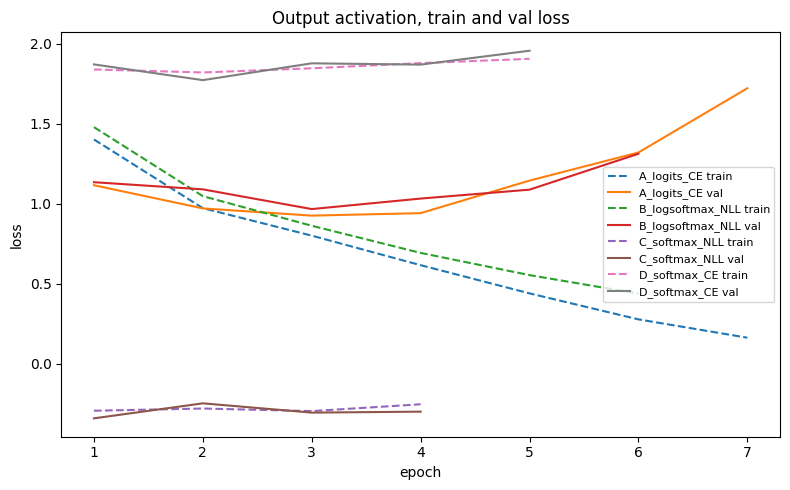

In [29]:
import matplotlib.pyplot as plt

# output activation, train and val loss for all four variants
fig, ax = plt.subplots(figsize=(8, 5))
for name, r in results_act.items():
    epochs = range(1, len(r["history"]["train_loss"]) + 1)
    ax.plot(epochs, r["history"]["train_loss"], "--", label=f"{name} train")
    ax.plot(epochs, r["history"]["val_loss"], "-",  label=f"{name} val")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_title("Output activation, train and val loss")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

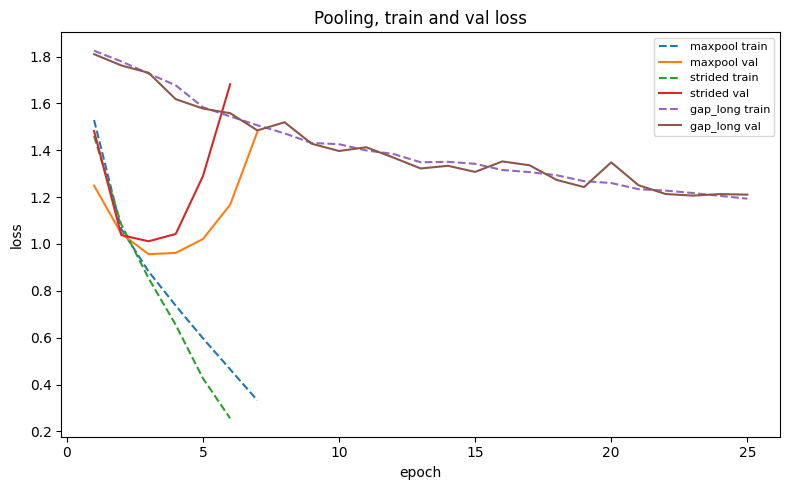

In [30]:
# pooling, train and val loss for the three variants, gap_long replaces gap
pool_to_plot = ["maxpool", "strided", "gap_long"]

fig, ax = plt.subplots(figsize=(8, 5))
for name in pool_to_plot:
    r = results_pool[name]
    epochs = range(1, len(r["history"]["train_loss"]) + 1)
    ax.plot(epochs, r["history"]["train_loss"], "--", label=f"{name} train")
    ax.plot(epochs, r["history"]["val_loss"], "-",  label=f"{name} val")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_title("Pooling, train and val loss")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

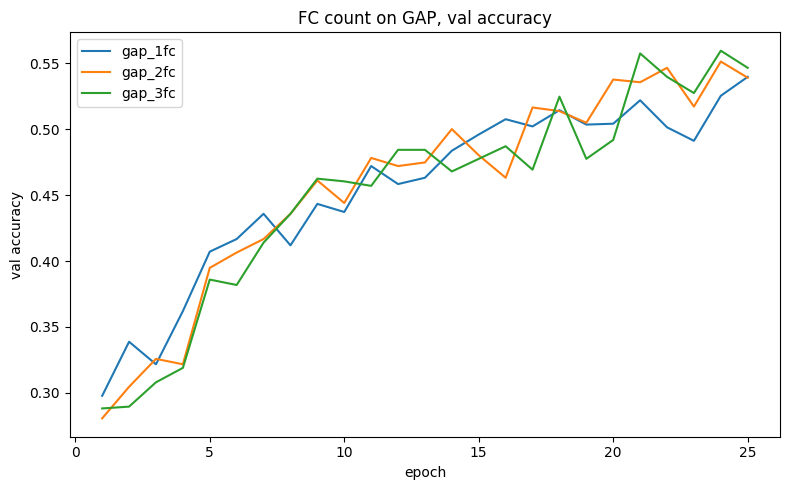

In [31]:
# FC count, val accuracy for the three GAP head depths
fig, ax = plt.subplots(figsize=(8, 5))
for name, r in results_fc.items():
    epochs = range(1, len(r["history"]["val_acc"]) + 1)
    ax.plot(epochs, r["history"]["val_acc"], label=name)
ax.set_xlabel("epoch")
ax.set_ylabel("val accuracy")
ax.set_title("FC count on GAP, val accuracy")
ax.legend()
plt.tight_layout()
plt.show()

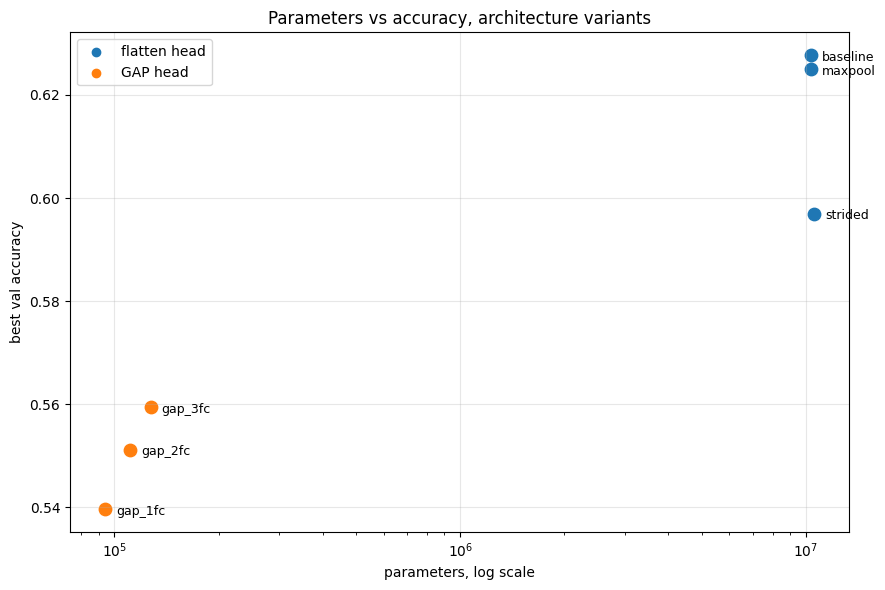

In [33]:
# params vs accuracy, architecture variants only, grouped by head type
flatten_pts = [
    ("baseline",  10_334_279, results_act["A_logits_CE"]["best_acc"]),
    ("maxpool",   results_pool["maxpool"]["n_params"],  results_pool["maxpool"]["best_acc"]),
    ("strided",   results_pool["strided"]["n_params"],  results_pool["strided"]["best_acc"]),
]

gap_pts = [
    ("gap_1fc", results_fc["gap_1fc"]["n_params"], results_fc["gap_1fc"]["best_acc"]),
    ("gap_2fc", results_fc["gap_2fc"]["n_params"], results_fc["gap_2fc"]["best_acc"]),
    ("gap_3fc", results_fc["gap_3fc"]["n_params"], results_fc["gap_3fc"]["best_acc"]),
]

fig, ax = plt.subplots(figsize=(9, 6))

for name, p, a in flatten_pts:
    ax.scatter(p, a, s=80, color="tab:blue")
    ax.annotate(name, (p, a), fontsize=9, xytext=(8, -4), textcoords="offset points")

for name, p, a in gap_pts:
    ax.scatter(p, a, s=80, color="tab:orange")
    ax.annotate(name, (p, a), fontsize=9, xytext=(8, -4), textcoords="offset points")

# legend by colour, not by point
ax.scatter([], [], color="tab:blue",   label="flatten head")
ax.scatter([], [], color="tab:orange", label="GAP head")
ax.legend()

ax.set_xscale("log")
ax.set_xlabel("parameters, log scale")
ax.set_ylabel("best val accuracy")
ax.set_title("Parameters vs accuracy, architecture variants")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()